In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as spe

In [3]:
r_max = 30.0
N = 1000
dr = r_max / (N + 1)
r = np.arange(1, N + 1) * dr
l = 0
V_eff = -1/r + l*(l+1)/(2*r**2)
diag = 1/dr**2 + V_eff
off_diag = -1/(2*dr**2) * np.ones(N-1)
H = (np.diag(diag)+np.diag(off_diag, 1)+ np.diag(off_diag, -1))  #hamiltoniano
E, u = np.linalg.eigh(H)             #Auto
print(E[:5])

[-0.49988778 -0.12499298 -0.05542226 -0.02463843  0.01331489]


In [4]:
for n in range(3):    #normalizar estado
    norm = np.sqrt(np.trapezoid(u[:, n]**2, x=r))
    u[:, n] /= norm

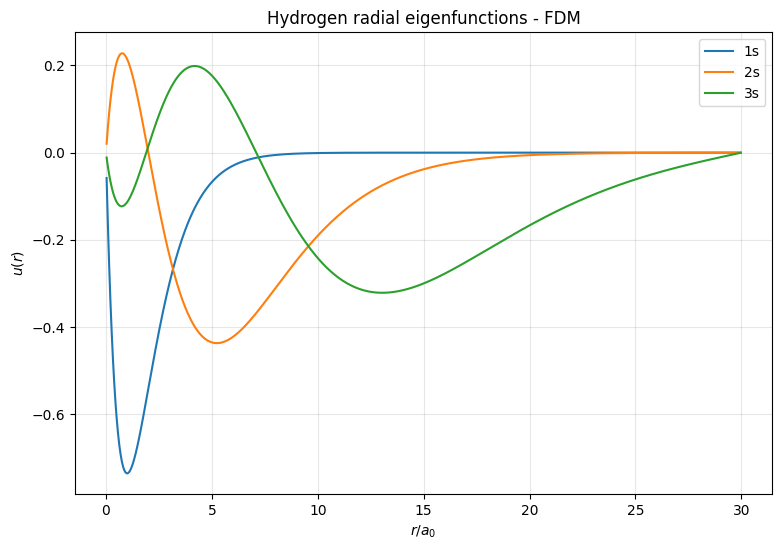

In [5]:
plt.figure(figsize=(9,6))
plt.plot(r, u[:,0], label='1s')
plt.plot(r, u[:,1], label='2s')
plt.plot(r, u[:,2], label='3s')
plt.xlabel(r'$r/a_0$')
plt.ylabel(r'$u(r)$')
plt.title('Hydrogen radial eigenfunctions - FDM')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

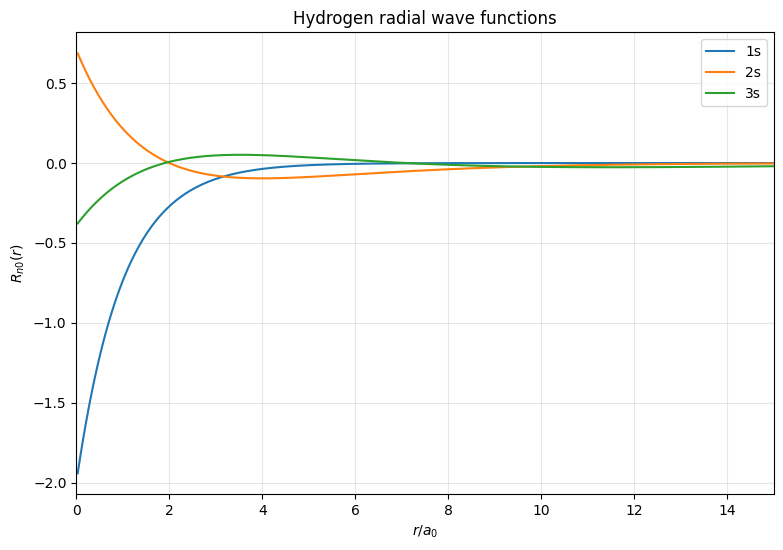

In [7]:
R = u / r[:, None]
plt.figure(figsize=(9,6))

plt.plot(r, R[:,0], label='1s')
plt.plot(r, R[:,1], label='2s')
plt.plot(r, R[:,2], label='3s')

plt.xlabel(r'$r/a_0$')
plt.ylabel(r'$R_{n0}(r)$')
plt.title('Hydrogen radial wave functions')

plt.xlim(0, 15)   # límite del eje x

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
def psi_R(r, n=1, l=0):
    coeff = np.sqrt(
        (2.0/n)**3
        * spe.factorial(n-l-1)
        / (2.0*n*spe.factorial(n+l)))
    laguerre = spe.assoc_laguerre(
        2.0*r/n,
        n-l-1,
        2*l+1)
    rho = 2.0*r/n
    return coeff*np.exp(-r/n)*rho**l*laguerre

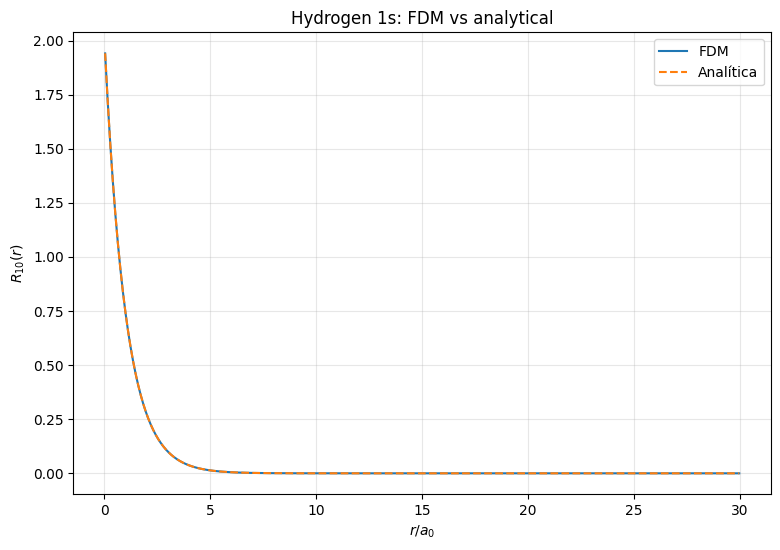

In [12]:
#slc exacta
R_exact = psi_R(r, n=1, l=0)

R_fdm = R[:,0]

# El signo global de un eigenvector es arbitrario
if np.dot(R_fdm, R_exact) < 0:
    R_fdm *= -1

plt.figure(figsize=(9,6))

plt.plot(r, R_fdm, label='FDM')
plt.plot(r, R_exact, '--', label='Analítica')

plt.xlabel(r'$r/a_0$')
plt.ylabel(r'$R_{10}(r)$')
plt.title('Hydrogen 1s: FDM vs analytical')
plt.legend()
plt.grid(alpha=0.3)

plt.show()